In [1]:
import pandas as pd
import numpy as np
import random

In [2]:


class QLearningProductionSystem:
    def __init__(self, max_inventory, min_inventory, max_production, max_demand, backorder_cost, epsilon=0.1, learning_rate=0.1, discount_factor=0.95):
        self.max_inventory = max_inventory
        self.min_inventory = min_inventory
        self.max_production = max_production
        self.max_demand = max_demand
        self.backorder_cost = backorder_cost
        self.epsilon = epsilon
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        # State space now includes inventory, demand, and forecast
        self.inventory_state_size = max_inventory - min_inventory + 1
        self.demand_state_size = max_demand + 1
        self.forecast_state_size = max_demand + 1
        self.action_size = max_production + 1
        # Expanding Q-table to include all dimensions
        self.q_table = np.zeros((self.inventory_state_size, self.demand_state_size, self.forecast_state_size, self.action_size))
        self.current_inventory = 0
        self.forecast = random.randint(0, self.max_demand)

    def get_state_indexes(self, inventory, demand, forecast):
        inventory_index = inventory - self.min_inventory
        demand_index = demand
        forecast_index = forecast
        return inventory_index, demand_index, forecast_index

    def choose_action(self, inventory, demand, forecast):
        inventory_index, demand_index, forecast_index = self.get_state_indexes(inventory, demand, forecast)
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, self.max_production)  # Explore
        else:
            return np.argmax(self.q_table[inventory_index, demand_index, forecast_index])  # Exploit

    def update_q_table(self, inventory, demand, forecast, action, reward, next_inventory):
        inventory_index, demand_index, forecast_index = self.get_state_indexes(inventory, demand, forecast)
        next_inventory_index = next_inventory - self.min_inventory
        # Assume next demand and forecast could be any, but for simplicity, use current demand, forecast for max future Q
        next_max_q = np.max(self.q_table[next_inventory_index, :, :, :])

        current_q_value = self.q_table[inventory_index, demand_index, forecast_index, action]
        # Q-learning update rule
        new_q_value = current_q_value + self.learning_rate * (reward + self.discount_factor * next_max_q - current_q_value)
        self.q_table[inventory_index, demand_index, forecast_index, action] = new_q_value

    def simulate(self, episodes):
        for episode in range(episodes):
            state = self.current_inventory
            demand = random.randint(0, self.max_demand)
            forecast = random.randint(0, self.max_demand)
            action = self.choose_action(state, demand, forecast)
            reward = self.get_reward(state, action, demand, forecast)
            next_state = max(self.min_inventory, min(self.max_inventory, state + action - demand))
            self.update_q_table(state, demand, forecast, action, reward, next_state)
            self.current_inventory = next_state
            self.forecast = forecast

            # Optionally update forecast here
    
    def get_reward(self, state, action, demand, forecast):
        new_inventory = state + action - demand
        # Costs and rewards parameters
        holding_cost_per_unit = 1  # Cost for holding one unit of inventory
        backorder_cost_per_unit = 5  # Cost for each unit backordered
        production_cost_per_unit = 2  # Cost for producing one unit
        sale_reward_per_unit = 10  # Reward for each unit sold (meeting demand)
        forecast_adjustment_factor = 10  # Additional reward factor for preparing for forecasted demand

        # Calculate base reward or penalty
        if new_inventory >= 0:
            # Inventory is sufficient to meet demand
            holding_cost = holding_cost_per_unit * new_inventory
            total_cost = holding_cost + action * production_cost_per_unit
            total_reward = demand * sale_reward_per_unit - total_cost
        else:
            # Inventory is not sufficient, leading to backorders
            backorder_cost = abs(new_inventory) * backorder_cost_per_unit
            total_cost = backorder_cost + action * production_cost_per_unit
            total_reward = demand * sale_reward_per_unit - total_cost

        # Adjust reward based on forecast
        if forecast > self.max_production:
            # When forecasted demand exceeds max production, incentivize building up inventory in advance
            required_inventory = forecast - self.max_production  # Required inventory to meet the forecasted demand
            if new_inventory >= required_inventory:
                # Provide an additional reward for having enough inventory to cover the gap between forecast and max production
                total_reward += 10
            if new_inventory >= required_inventory+1:
                total_reward += 20
            if new_inventory >= required_inventory+2:
                total_reward += 40

        # Bonus for maintaining optimal inventory level
        optimal_inventory_level = 2  # Defined optimal inventory level (safety stock)
        if  new_inventory == optimal_inventory_level:
            # Adding a small bonus for keeping inventory within the optimal range
            total_reward += 20
        if  new_inventory == optimal_inventory_level-1:
            # Adding a small bonus for keeping inventory within the optimal range
            total_reward += 10

        return total_reward

    def evaluate_agent(self, episodes):
        total_reward = 0
        demand_met_count = 0
        episode_data = []
        self.current_inventory = 0

        for episode in range(episodes):
            state = self.current_inventory
            demand = self.forecast
            forecast = random.randint(0, self.max_demand)
            # Choose the best action based on Q-table, not exploring
            inventory_index, demand_index, forecast_index = self.get_state_indexes(state, demand, forecast)
            action = np.argmax(self.q_table[inventory_index, demand_index, forecast_index])
            
            reward = self.get_reward(state, action, demand, forecast)
            total_reward += reward

            # Update current inventory, keeping it within set limits
            self.current_inventory = max(self.min_inventory, min(self.max_inventory, state + action - demand))
            self.forecast = forecast

            if state + action >= demand:
                demand_met_count += 1

            # Store state, demand, action, and reward for each episode
            episode_data.append((episode, state, demand, forecast, action, reward))
            # Printing the demand and action for each episode
            #print(f"Episode {episode + 1}: Demand = {demand}, Action = {action}, State = {state}")
        average_reward = total_reward / episodes
        demand_met_rate = demand_met_count / episodes

        return average_reward, demand_met_rate, episode_data

    def save_q_table_to_csv(self, file_path):
        # Flatten the Q-table into a list of rows, each row representing state, action, and corresponding Q-value
        records = []
        for inventory_index in range(self.q_table.shape[0]):
            for demand_index in range(self.q_table.shape[1]):
                for forecast_index in range(self.q_table.shape[2]):
                    for action_index in range(self.q_table.shape[3]):
                        q_value = self.q_table[inventory_index, demand_index, forecast_index, action_index]
                        records.append([inventory_index, demand_index, forecast_index, action_index, q_value])

        # Convert the list of rows into a DataFrame
        df = pd.DataFrame(records, columns=['InventoryIndex', 'DemandIndex', 'ForecastIndex', 'ActionIndex', 'QValue'])

        # Save the DataFrame to a CSV file
        df.to_csv(file_path, index=False)
        print(f"Q-table saved to {file_path}")


In [3]:
# Example usage
max_inventory = 6
min_inventory = -5
max_production = 5
max_demand = 7
backorder_cost =1
epsilon = 0.1  # Exploration rate
learning_rate = 0.1
discount_factor = 0.95

system = QLearningProductionSystem(max_inventory, min_inventory, max_production, max_demand, backorder_cost, epsilon, learning_rate, discount_factor)

system.simulate(episodes=50000000)
print(system.q_table)
system.save_q_table_to_csv('Q_Values.csv')

[[[[1869.77499916 1899.84997562 1939.42499851 1969.49997026
    1981.99999999 1994.5       ]
   [1869.77499172 1899.84999955 1939.42499879 1969.49999817
    1981.99999982 1994.5       ]
   [1869.77499919 1899.8499893  1939.42499879 1969.49999618
    1981.99999965 1994.5       ]
   ...
   [1869.77499857 1899.84999765 1939.42499502 1969.49999966
    1981.99999727 1994.5       ]
   [1869.77499262 1899.84999962 1939.42499472 1969.49999867
    1982.         1994.5       ]
   [1869.77499976 1899.84999865 1939.42498205 1969.49992936
    1981.99999968 1994.5       ]]

  [[1874.77499645 1877.77498682 1907.84998712 1947.42499994
    1977.49998211 1990.        ]
   [1874.77499689 1877.77499526 1907.84999776 1947.42499971
    1977.49999023 1990.        ]
   [1874.77499906 1877.774996   1907.84999704 1947.42499983
    1977.49999662 1990.        ]
   ...
   [1874.77499561 1877.77499196 1907.84999788 1947.42499882
    1977.4999773  1990.        ]
   [1874.77499788 1877.77499953 1907.84999935 1947.424

In [24]:
# Evaluate the trained agent and observe output directly from the method
evaluation_episodes = 25  # Set to a smaller number for demonstration
average_reward, demand_met_rate, Episode_data = system.evaluate_agent(evaluation_episodes)

# Print summary statistics
print(f"\nAverage Reward over {evaluation_episodes} evaluation episodes: {average_reward}")
print(f"Demand Met Rate over {evaluation_episodes} evaluation episodes: {demand_met_rate:.2%}")
print(f"Episode data: {Episode_data}")
#episode, state, demand, forecast, action, reward


Average Reward over 25 evaluation episodes: 34.32
Demand Met Rate over 25 evaluation episodes: 100.00%
Episode data: [(0, 0, 3, 7, 5, 48), (1, 2, 7, 3, 5, 60), (2, 0, 3, 4, 5, 38), (3, 2, 4, 2, 4, 50), (4, 2, 2, 3, 2, 34), (5, 2, 3, 3, 3, 42), (6, 2, 3, 5, 3, 42), (7, 2, 5, 3, 5, 58), (8, 2, 3, 0, 3, 42), (9, 2, 0, 5, 4, -14), (10, 6, 5, 3, 5, 34), (11, 6, 3, 3, 3, 18), (12, 6, 3, 0, 3, 18), (13, 6, 0, 4, 0, -6), (14, 6, 4, 6, 4, 96), (15, 6, 6, 2, 2, 74), (16, 2, 2, 0, 2, 34), (17, 2, 0, 3, 4, -14), (18, 6, 3, 3, 3, 18), (19, 6, 3, 1, 3, 18), (20, 6, 1, 1, 1, 2), (21, 6, 1, 1, 1, 2), (22, 6, 1, 2, 1, 2), (23, 6, 2, 7, 2, 80), (24, 6, 7, 0, 3, 82)]


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have already run the simulation and have the episode_data
average_reward, demand_met_rate, episode_data = system.evaluate_agent(25)

# Convert data to DataFrame for easier plotting
df = pd.DataFrame(episode_data, columns=['Episode', 'State', 'Demand','Forecast', 'Action', 'Reward'])

# Set up the figure
plt.figure(figsize=(15, 7))
width = 0.15  # Width of the bars

# Iterate over episodes to plot bars and add reward text
for i in range(len(df)):
    # State + Action stacked bar
    plt.bar(i - width, df.loc[i, 'State'], width, label='Inventory' if i == 0 else "", color='blue')
    plt.bar(i - width, df.loc[i, 'Action'], width, bottom=df.loc[i, 'State'], label='Production' if i == 0 else "", color='red')

    # Demand bar
    plt.bar(i, df.loc[i, 'Demand'], width, label='Demand' if i == 0 else "", color='orange')

    # Forecast bar
    plt.bar(i + width/2, df.loc[i, 'Forecast'], width, label='Forecast' if i == 0 else "", color='green')

    # Add reward text
    reward = df.loc[i, 'Reward']
    plt.text(i, -0.5, f'{reward:.1f}', ha='center', va='top', color='green', fontsize=8)

# Add labels and title
plt.xlabel('Episode')
plt.ylabel('Values')
plt.title('Invntory + Production, Demand, Forecast and Reward over Episodes')
plt.xticks(range(len(df)), df['Episode'])

# Add legend
plt.legend()

# Show plot
plt.show()


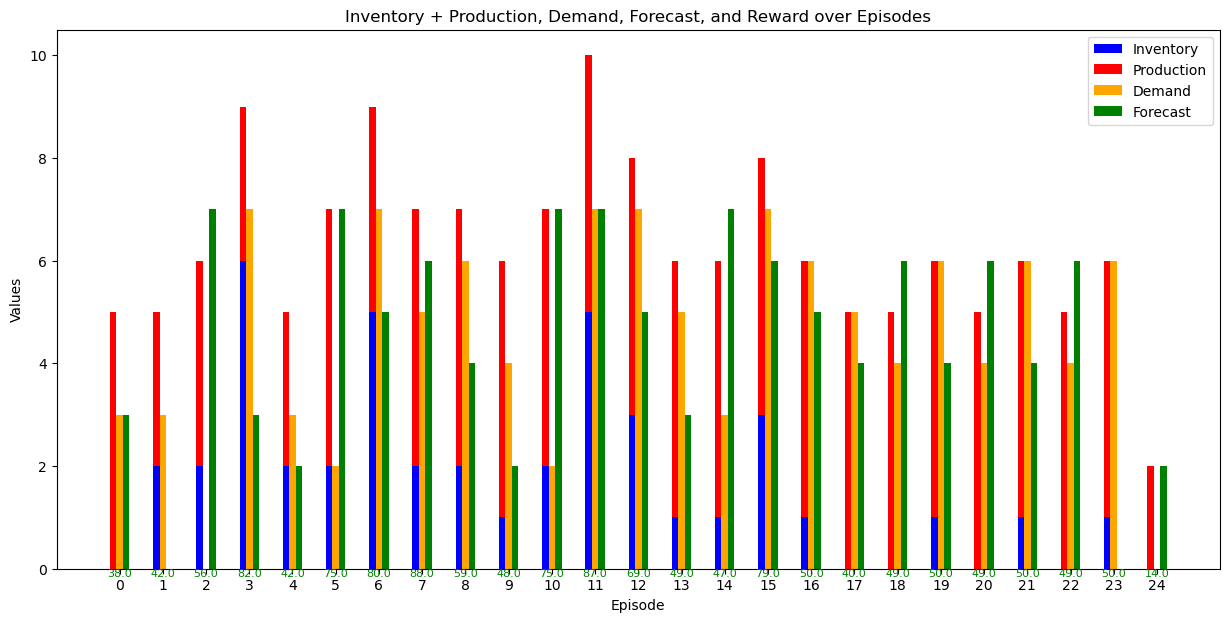

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have already run the simulation and have the episode_data
average_reward, demand_met_rate, episode_data = system.evaluate_agent(25)

# Convert data to DataFrame for easier plotting
df = pd.DataFrame(episode_data, columns=['Episode', 'State', 'Demand', 'Forecast', 'Action', 'Reward'])

# Set up the figure
plt.figure(figsize=(15, 7))
width = 0.15  # Adjust width to fit all bars

# Iterate over episodes to plot bars and add reward text
for i in range(len(df)):
    state = df.loc[i, 'State']
    action = df.loc[i, 'Action']
    demand = df.loc[i, 'Demand']
    forecast = df.loc[i, 'Forecast']

    # Plotting state and action
    if state >= 0:
        plt.bar(i - width, state, width, label='Inventory' if i == 0 else "", color='blue')
    else:
        plt.plot(i - width, abs(state), width, label='Backorder' if i == 0 else "", color='cyan', linestyle='none', marker='o')
    plt.bar(i - width, action, width, bottom=max(state, 0), label='Production' if i == 0 else "", color='red')
    
    # Plotting demand and forecast with adjusted positions
    plt.bar(i, demand, width, label='Demand' if i == 0 else "", color='orange')
    plt.bar(i + width, forecast, width, label='Forecast' if i == 0 else "", color='green')

    # Add reward text
    reward = df.loc[i, 'Reward']
    plt.text(i, df['State'].min() - abs(df['State'].min() * 0.1), f'{reward:.1f}', ha='center', va='top', color='green', fontsize=8)

# Add labels and title
plt.xlabel('Episode')
plt.ylabel('Values')
plt.title('Inventory + Production, Demand, Forecast, and Reward over Episodes')
plt.xticks(range(len(df)), df['Episode'])

# Add legend
plt.legend()

# Show plot
plt.show()


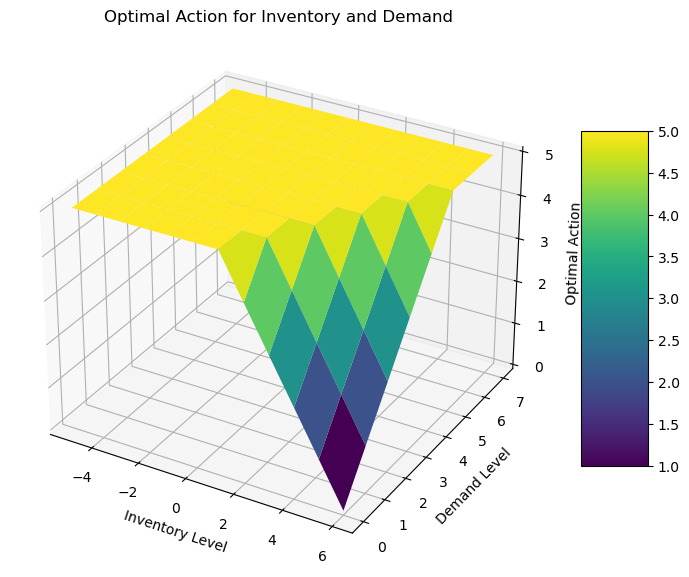

In [32]:
# Plot to Visualaze Q-Learning:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

max_inventory = 6
min_inventory = -5
max_production = 5
max_demand = 7
backorder_cost =1
epsilon = 0.1  # Exploration rate
learning_rate = 0.1
discount_factor = 0.95


# Assuming q_learning_system is an instance of QLearningProductionSystem
q_table = system.q_table
fixed_forecast_index = 7  # Example: Choose a specific forecast value for visualization

# Prepare data for plotting
inventory_levels = np.arange(min_inventory, max_inventory + 1)
demand_levels = np.arange(0, max_demand + 1)
X, Y = np.meshgrid(inventory_levels, demand_levels)
Z = np.zeros(X.shape)
A = np.zeros(X.shape)

for i, inventory in enumerate(inventory_levels):
    for j, demand in enumerate(demand_levels):
        inventory_index, demand_index, _ = system.get_state_indexes(inventory, demand, fixed_forecast_index)
        # Find the action with the highest Q-value for the current state
        action = np.argmax(q_table[inventory_index, demand_index, fixed_forecast_index, :])
        A[j, i] = action
        # Store the highest Q-value for plotting
        Z[j, i] = np.max(q_table[inventory_index, demand_index, fixed_forecast_index, :])

# Plotting
fig = plt.figure(figsize=(14, 7))

# Plot for Actions
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, A, cmap='viridis', edgecolor='none')
ax1.set_xlabel('Inventory Level')
ax1.set_ylabel('Demand Level')
ax1.set_zlabel('Optimal Action')
ax1.set_title('Optimal Action for Inventory and Demand')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

# # Plot for Q-Values
# ax2 = fig.add_subplot(122, projection='3d')
# surf = ax2.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none')
# ax2.set_xlabel('Inventory Level')
# ax2.set_ylabel('Demand Level')
# ax2.set_zlabel('Highest Q-Value')
# ax2.set_title('Highest Q-Value for Inventory and Demand')
# fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()


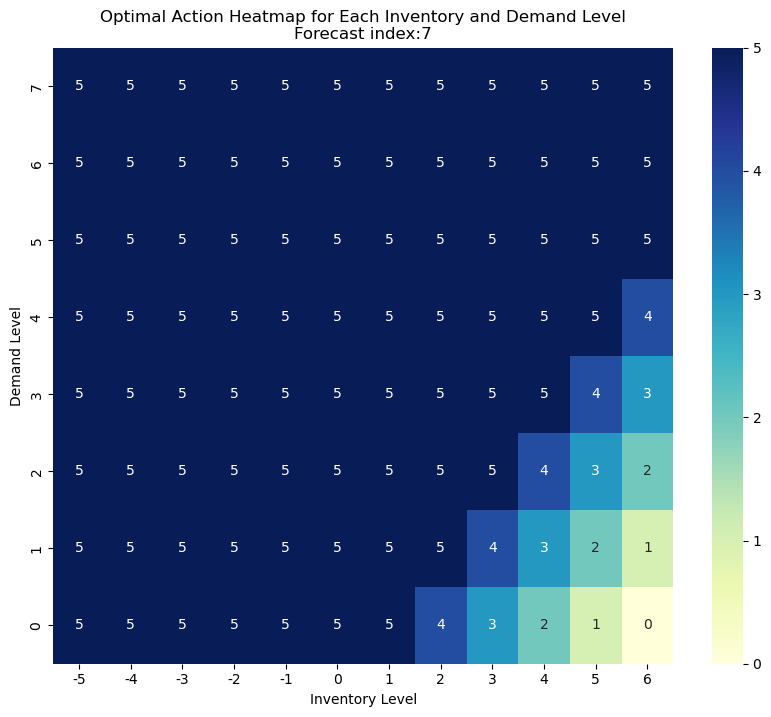

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming q_learning_system is an instance of QLearningProductionSystem
q_table = system.q_table
fixed_forecast_index = 7  # For example, selecting a specific forecast value for visualization

# Prepare data for plotting
inventory_levels = np.arange(min_inventory, max_inventory + 1)
demand_levels = np.arange(0, max_demand + 1)
actions_matrix = np.zeros((len(demand_levels), len(inventory_levels)))

for i, inventory in enumerate(inventory_levels):
    for j, demand in enumerate(demand_levels):
        inventory_index, demand_index, _ = system.get_state_indexes(inventory, demand, fixed_forecast_index)
        # Find the action with the highest Q-value for the current state
        action = np.argmax(q_table[inventory_index, demand_index, fixed_forecast_index, :])
        actions_matrix[j, i] = action

# Plotting using seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(actions_matrix, annot=True, fmt=".0f", cmap='YlGnBu', xticklabels=inventory_levels, yticklabels=demand_levels)
plt.title(f'Optimal Action Heatmap for Each Inventory and Demand Level\nForecast index:{fixed_forecast_index}')
plt.xlabel('Inventory Level')
plt.ylabel('Demand Level')
plt.gca().invert_yaxis()  # To align the origin (0,0) to the bottom left corner
plt.show()


In [ ]:
#Next steps
# 1) Introduce a demand forecast into the state space and reward it for meeting future excess demand
# 2) See if it can switch demand patterns quickly 
# 3) Q-learning implementaion to achive the same result
# 4) Write a LP program of this